# Review of danger level crossings

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr
from datetime import timedelta
from pathlib import Path
import os

In [3]:
file_path = (
    Path(os.getenv("AA_DATA_DIR"))
    / "private"
    / "exploration"
    / "npl"
    / "dhm"
    / "processed"
    / "waterl_level_procssed.csv"
)
npl_data = pd.read_csv(file_path)
npl_data["date"] = pd.to_datetime(npl_data["date"])

In [4]:
npl_data.columns

Index(['date', 'Chatara', 'Chisapani', 'Asaraghat', 'Chepang', 'Kusum'], dtype='object')

In [5]:
# now, check when the danger levels were crossed
chatara_dl = 7
chisapani_dl = 10.5

Text(2014-10-02 00:00:00, 7.1, 'Chatara Danger Level')

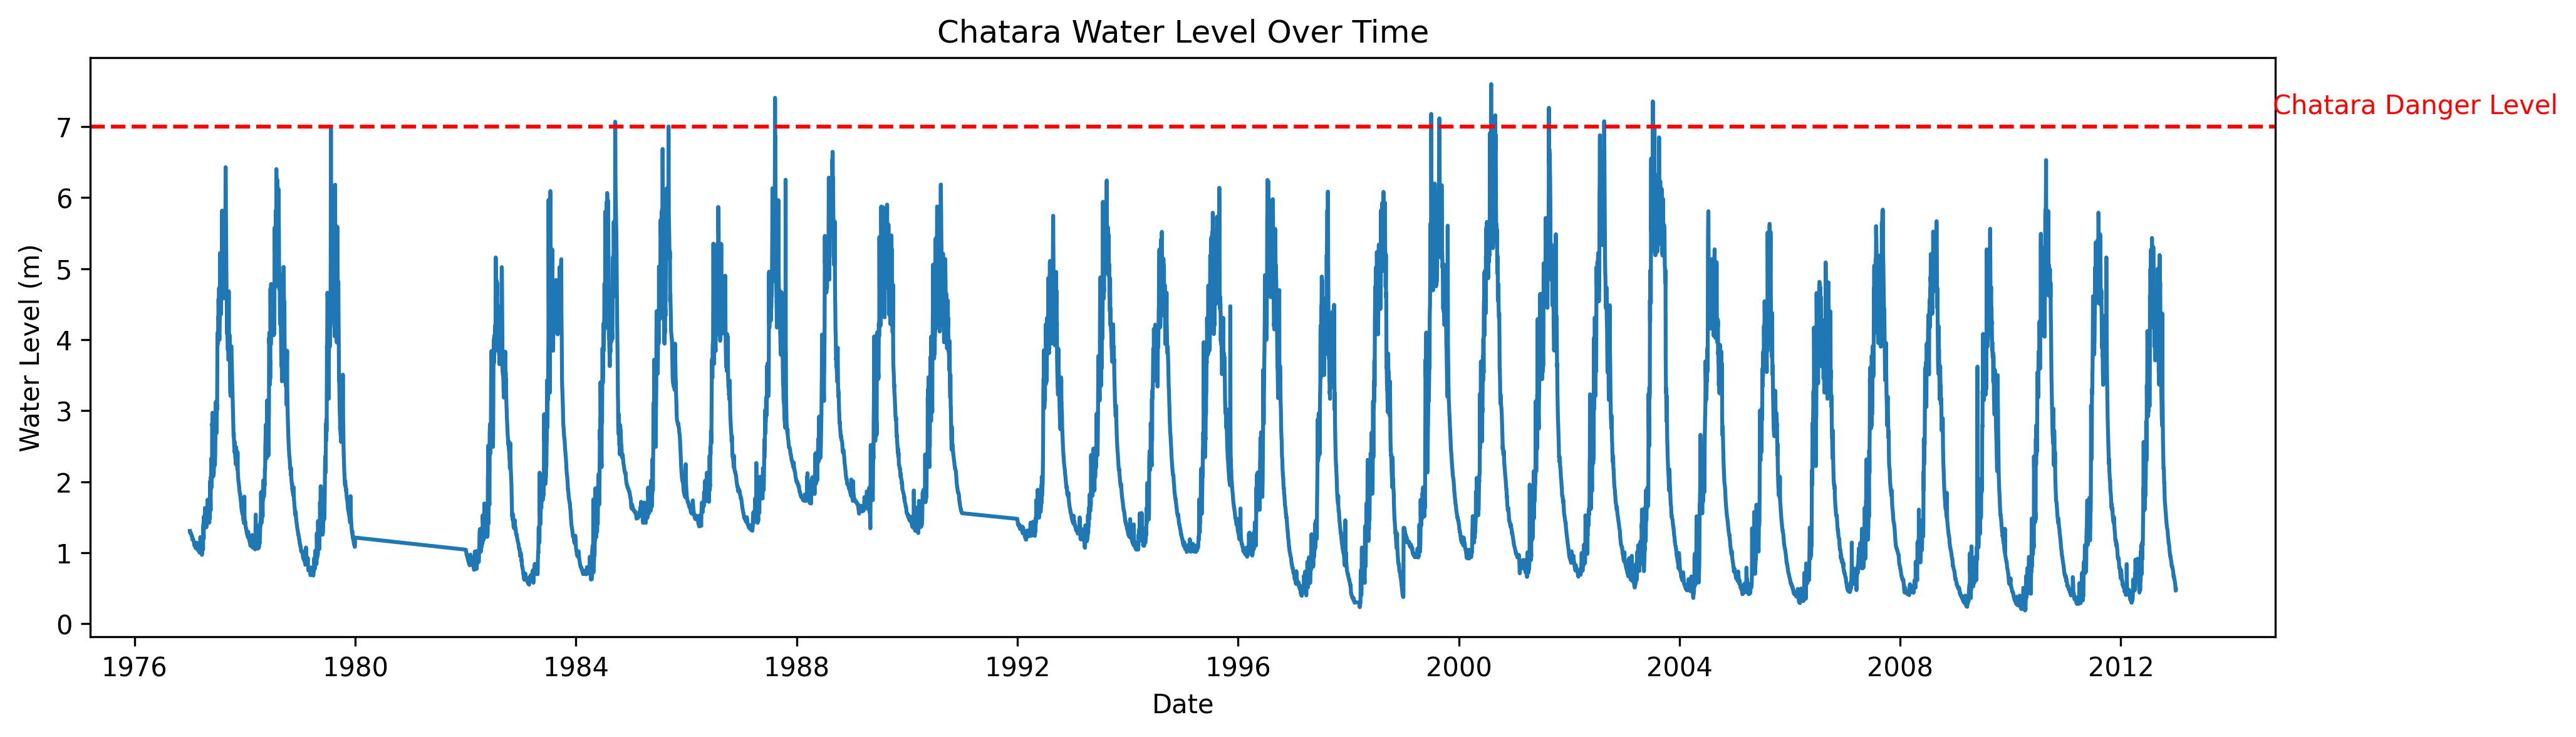

In [6]:
# plot the chatara and chisapani water levels
fig, ax = plt.subplots(figsize=(15, 4), dpi=300)
sns.lineplot(
    data=npl_data,
    x="date",
    y="Chatara",
    ax=ax,
)
ax.set_title("Chatara Water Level Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Water Level (m)")
# add horizontal line for danger level
ax.axhline(chatara_dl, color="red", linestyle="--", label="Chatara Danger Level")
ax.text(
    npl_data["date"].max() - pd.Timedelta(weeks=65),
    chatara_dl + 0.1,
    "Chatara Danger Level",
    color="red",
    fontsize=10,
    va="bottom",
)

Text(2015-01-15 00:00:00, 10.6, 'Chisapani Danger Level')

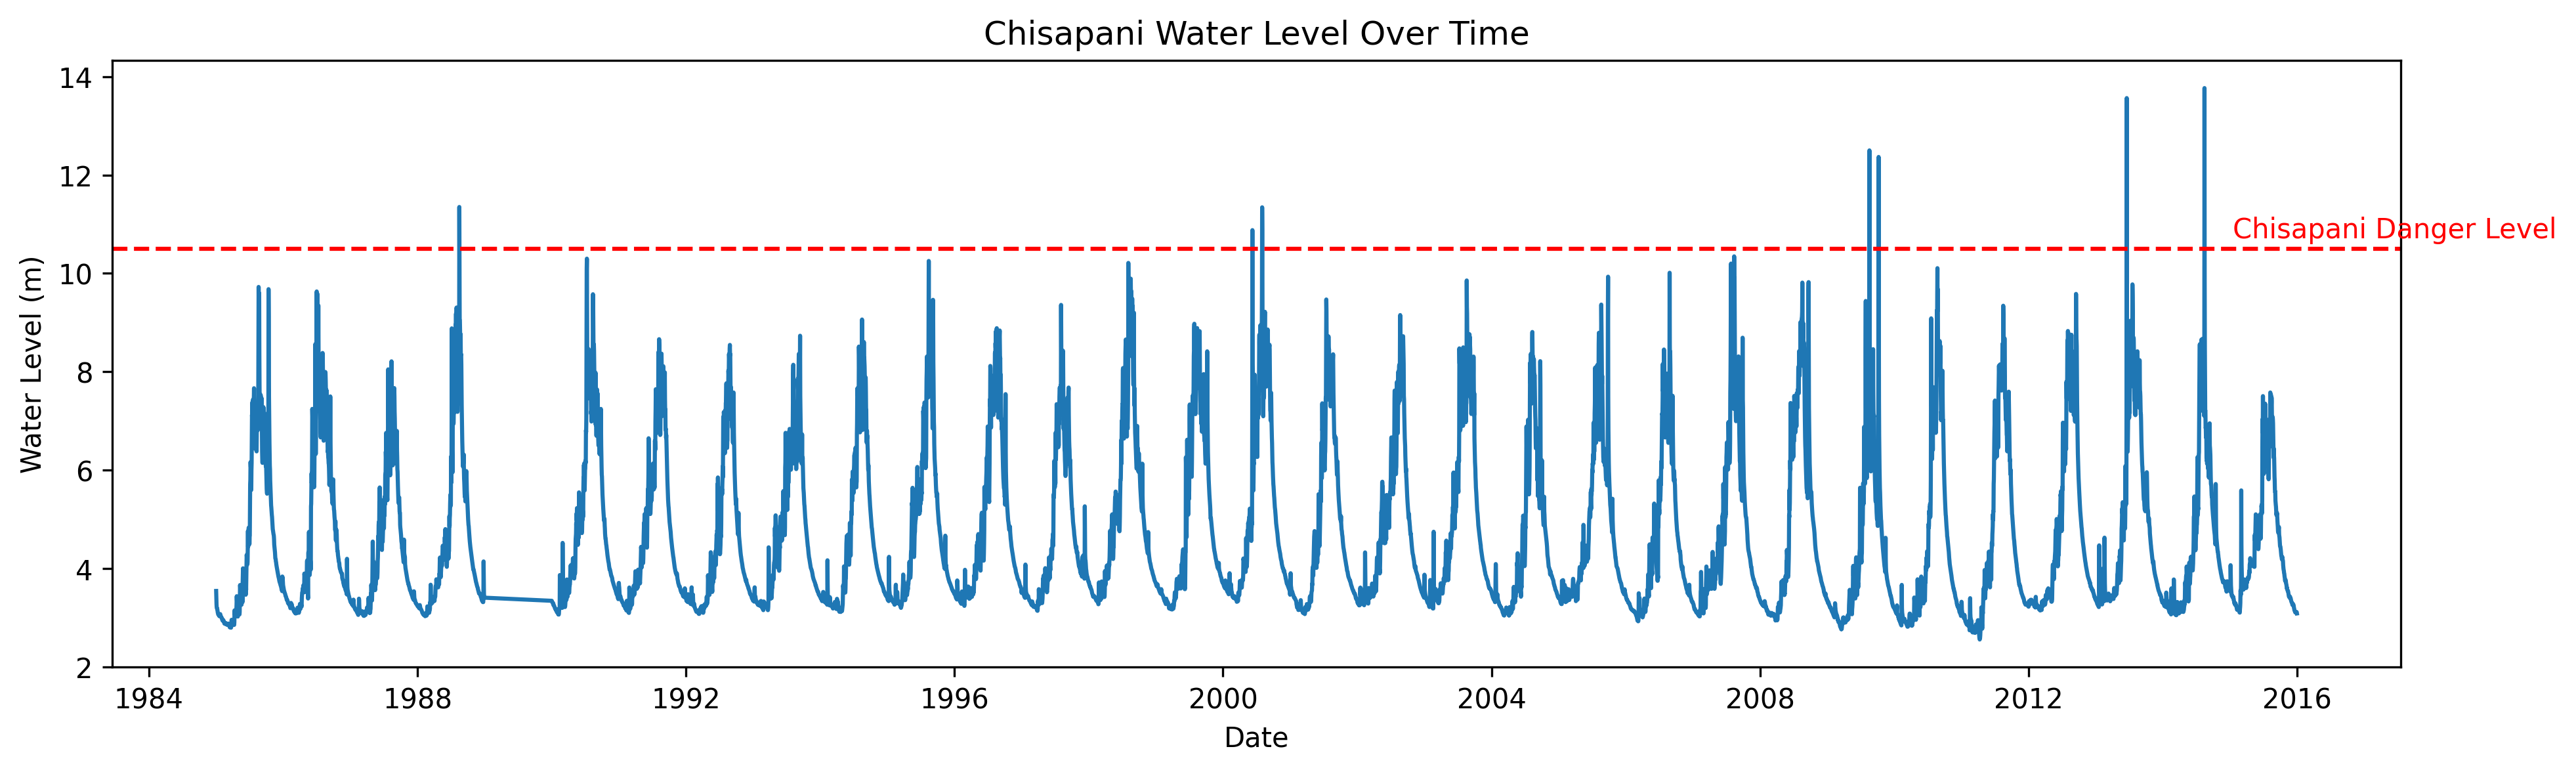

In [7]:
# plot the chatara and chisapani water levels
fig, ax = plt.subplots(figsize=(15, 4), dpi=300)
sns.lineplot(
    data=npl_data,
    x="date",
    y="Chisapani",
    ax=ax,
)
ax.set_title("Chisapani Water Level Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Water Level (m)")
# add horizontal line for danger level
ax.axhline(chisapani_dl, color="red", linestyle="--", label="Chisapani Danger Level")
ax.text(
    npl_data["date"].max() - pd.Timedelta(weeks=50),
    chisapani_dl + 0.1,
    "Chisapani Danger Level",
    color="red",
    fontsize=10,
    va="bottom",
)

In [8]:
# this just caught the peak of the water level
# Detect crossings for Chatara
npl_data["chatara_exceed"] = npl_data["Chatara"] > chatara_dl
npl_data["chatara_cross"] = npl_data["chatara_exceed"].astype(int).diff() == 1

# Detect crossings for Chisapani
npl_data["chisapani_exceed"] = npl_data["Chisapani"] > chisapani_dl
npl_data["chisapani_cross"] = npl_data["chisapani_exceed"].astype(int).diff() == 1

# Extract dates
chatara_crossings = npl_data.loc[npl_data["chatara_cross"], "date"].to_frame()
chatara_crossings["location"] = "Chatara"

chisapani_crossings = npl_data.loc[npl_data["chisapani_cross"], "date"].to_frame()
chisapani_crossings["location"] = "Chisapani"
crossings_df = pd.concat([chatara_crossings, chisapani_crossings])
crossings_df["year"] = crossings_df["date"].dt.year
crossings_df["month"] = crossings_df["date"].dt.month_name()

# Optional: Sort the table
crossings_df = crossings_df.sort_values("date").reset_index(drop=True)

# Display selected columns
crossings_df[["location", "date", "month", "year"]]

,location,date,month,year
0,Chatara,1984-09-17,September,1984
1,Chatara,1987-08-11,August,1987
2,Chisapani,1988-08-16,August,1988
3,Chatara,1999-07-03,July,1999
4,Chatara,1999-08-26,August,1999
5,Chisapani,2000-06-09,June,2000
6,Chisapani,2000-08-01,August,2000
7,Chatara,2000-08-02,August,2000
8,Chatara,2000-08-30,August,2000
9,Chatara,2001-08-20,August,2001


In [9]:
# read in the GloFAS data from netcdf file
glofas_reanalysis_file_path = (
    Path(os.getenv("AA_DATA_DIR"))
    / "public"
    / "processed"
    / "npl"
    / "glofas"
    / "npl_cems-glofas-historical_v4.nc"
)
glofas_reanalysis_data = xr.open_dataset(glofas_reanalysis_file_path)
glofas_reanalysis_data

C:\Users\pauni\AppData\Local\Temp\ipykernel_1588\1664365758.py:10: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  glofas_reanalysis_data = xr.open_dataset(glofas_reanalysis_file_path)


<xarray.Dataset> Size: 460kB
Dimensions:     (time: 16436)
Coordinates:
  * time        (time) datetime64[ns] 131kB 1979-01-01 1979-01-02 ... 2023-12-31
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
    valid_time  (time) datetime64[ns] 131kB ...
Data variables:
    Rai_Goan    (time) float32 66kB ...
    Chatara     (time) float32 66kB ...
    Chisapani   (time) float32 66kB ...

In [10]:
df = glofas_reanalysis_data.to_dataframe().reset_index()
df.head()

,time,Rai_Goan,Chatara,Chisapani,step,surface,valid_time
0,1979-01-01,0.734375,362.031250,243.390625,1 days,0.0,1979-01-02
1,1979-01-02,0.734375,361.140625,241.390625,1 days,0.0,1979-01-03
2,1979-01-03,0.734375,357.843750,239.187500,1 days,0.0,1979-01-04
3,1979-01-04,0.718750,352.796875,237.046875,1 days,0.0,1979-01-05
4,1979-01-05,0.703125,348.937500,235.203125,1 days,0.0,1979-01-06


In [11]:
# computing the return levels for the GloFAS data
def compute_return_levels(data, return_periods):
    """
    Compute return levels from daily data for given return periods.

    Parameters:
    - daily_data: xarray.DataArray with 'time' coordinate
    - return_periods: list of return periods in years

    Returns:
    - dict of return levels for each return period
    """
    # Compute annual maxima
    annual_maxima = data.groupby("time.year").max(dim="time").values
    annual_maxima = np.sort(annual_maxima[~np.isnan(annual_maxima)])
    n = len(annual_maxima)

    # Empirical return level estimation
    return_levels = {}
    for rp in return_periods:
        rank = (1 - 1 / rp) * (n + 1)
        idx = int(np.floor(rank)) - 1
        if 0 <= idx < n - 1:
            frac = rank - (idx + 1)
            val = annual_maxima[idx] + frac * (
                annual_maxima[idx + 1] - annual_maxima[idx]
            )
        else:
            val = annual_maxima[min(max(idx, 0), n - 1)]
        return_levels[rp] = val
    return return_levels

In [12]:
stations = ["Chisapani", "Chatara"]
return_periods = [2, 5, 10, 20, 50, 100]
results = []

for station in stations:
    water_levels = glofas_reanalysis_data[station]
    return_levels = compute_return_levels(water_levels, return_periods)
    df_stat = pd.DataFrame.from_dict(
        return_levels, orient="index", columns=["Return Level (m)"]
    )
    df_stat["Return Period (years)"] = df_stat.index
    df_stat["Station"] = station
    results.append(df_stat.reset_index(drop=True))

final_df = pd.concat(results, ignore_index=True)
final_df = final_df[["Station", "Return Period (years)", "Return Level (m)"]]
final_df

,Station,Return Period (years),Return Level (m)
0,Chisapani,2,5847.203125
1,Chisapani,5,6747.484375
2,Chisapani,10,7424.384277
3,Chisapani,20,7935.492188
4,Chisapani,50,8816.375000
5,Chisapani,100,8816.375000
6,Chatara,2,7830.796875
7,Chatara,5,9716.265625
8,Chatara,10,11407.728516
9,Chatara,20,14395.504883


In [13]:
# using RP from the online dashboard
# https://global-flood.emergency.copernicus.eu/glofas-forecasting/
chatara_rp_2 = 8113
chatara_rp_5 = 10306
chisapani_rp_2 = 5664
chisapani_rp_5 = 6797
raigoan_rp_2 = 2690
raigoan_rp_5 = 4222

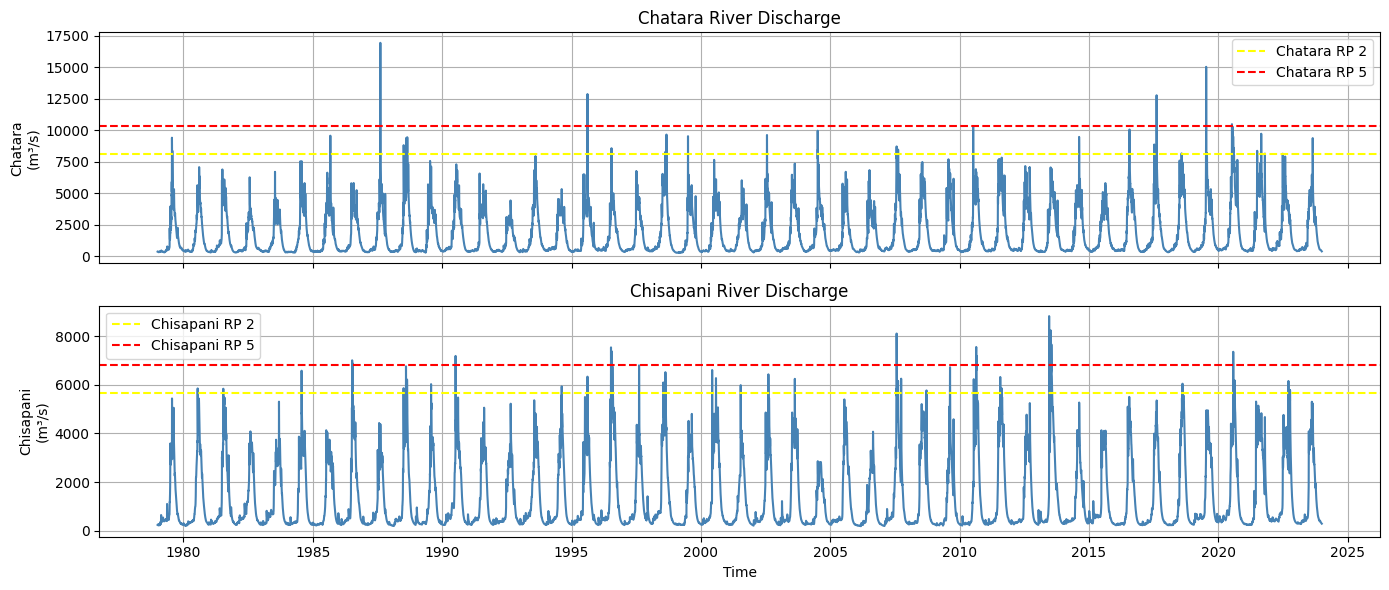

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# axes[0].plot(df["time"], df["Rai_Goan"], color="steelblue")
# axes[0].axhline(raigoan_rp_2, color="yellow", linestyle="--", label="Rai_Goan RP 2")
# axes[0].axhline(raigoan_rp_5, color="red", linestyle="--", label="Rai_Goan RP 5")
# axes[0].set_ylabel("Rai_Goan\n(m³/s)")
# axes[0].set_title("Rai_Goan River Discharge")
# axes[0].legend()

axes[0].plot(df["time"], df["Chatara"], color="steelblue")
axes[0].axhline(chatara_rp_2, color="yellow", linestyle="--", label="Chatara RP 2")
axes[0].axhline(chatara_rp_5, color="red", linestyle="--", label="Chatara RP 5")
axes[0].set_ylabel("Chatara\n(m³/s)")
axes[0].set_title("Chatara River Discharge")
axes[0].legend()

axes[1].plot(df["time"], df["Chisapani"], color="steelblue")
axes[1].axhline(chisapani_rp_2, color="yellow", linestyle="--", label="Chisapani RP 2")
axes[1].axhline(chisapani_rp_5, color="red", linestyle="--", label="Chisapani RP 5")
axes[1].set_ylabel("Chisapani\n(m³/s)")
axes[1].set_title("Chisapani River Discharge")
axes[1].set_xlabel("Time")
axes[1].legend()

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# checking if activations are close to each other
# Crossings above 2-year return level
rp2_chatara = df[df["Chatara"] > chatara_rp_2][["time", "Chatara"]].copy()
rp2_chatara["location"] = "Chatara"
rp2_chatara["value"] = rp2_chatara["Chatara"]
rp2_chatara = rp2_chatara[["location", "time", "value"]]

rp2_chisapani = df[df["Chisapani"] > chisapani_rp_2][["time", "Chisapani"]].copy()
rp2_chisapani["location"] = "Chisapani"
rp2_chisapani["value"] = rp2_chisapani["Chisapani"]
rp2_chisapani = rp2_chisapani[["location", "time", "value"]]

rp2 = pd.concat([rp2_chatara, rp2_chisapani], ignore_index=True)
rp2["month"] = rp2["time"].dt.month_name()
rp2["year"] = rp2["time"].dt.year
rp2 = rp2.rename(columns={"time": "date"})
rp2 = rp2[["location", "date", "month", "year", "value"]]

# Crossings above 5-year return level
rp5_chatara = df[df["Chatara"] > chatara_rp_5][["time", "Chatara"]].copy()
rp5_chatara["location"] = "Chatara"
rp5_chatara["value"] = rp5_chatara["Chatara"]
rp5_chatara = rp5_chatara[["location", "time", "value"]]

rp5_chisapani = df[df["Chisapani"] > chisapani_rp_5][["time", "Chisapani"]].copy()
rp5_chisapani["location"] = "Chisapani"
rp5_chisapani["value"] = rp5_chisapani["Chisapani"]
rp5_chisapani = rp5_chisapani[["location", "time", "value"]]

rp5 = pd.concat([rp5_chatara, rp5_chisapani], ignore_index=True)
rp5["month"] = rp5["time"].dt.month_name()
rp5["year"] = rp5["time"].dt.year
rp5 = rp5.rename(columns={"time": "date"})
rp5 = rp5[["location", "date", "month", "year", "value"]]

In [16]:
rp2[["location", "month", "year"]].drop_duplicates().sort_values(
    ["location", "year", "month"]
).reset_index()

,index,location,month,year
0,0,Chatara,July,1979
1,3,Chatara,September,1985
2,4,Chatara,August,1987
3,11,Chatara,August,1988
4,9,Chatara,July,1988
...,...,...,...,...
59,177,Chisapani,August,2018
60,181,Chisapani,August,2020
61,178,Chisapani,July,2020
62,184,Chisapani,October,2022


In [17]:
rp2.tail(5)

,location,date,month,year,value
181,Chisapani,2020-08-19,August,2020,6174.093750
182,Chisapani,2020-08-20,August,2020,6004.671875
183,Chisapani,2022-09-16,September,2022,6152.843750
184,Chisapani,2022-10-07,October,2022,5779.453125
185,Chisapani,2022-10-09,October,2022,5767.632812


In [18]:
rp5[["location", "month", "year"]].drop_duplicates().sort_values(
    ["location", "year", "month"]
).reset_index()

,index,location,month,year
0,0,Chatara,August,1987
1,3,Chatara,August,1995
2,5,Chatara,August,2017
3,7,Chatara,July,2019
4,10,Chatara,July,2020
5,11,Chisapani,July,1986
6,14,Chisapani,July,1990
7,15,Chisapani,July,1996
8,18,Chisapani,July,2007
9,20,Chisapani,August,2010


In [19]:
# comparing DHM crossings with GloFAS crossings
# Matched events (within ±7 days per location)
# keeping only GloFAS data that is within max date of DHM data
max_chatara_date = crossings_df["date"].max()
crossings_df["date"] = pd.to_datetime(crossings_df["date"])
rp2["date"] = pd.to_datetime(rp2["date"])

# Unique locations
locations = crossings_df["location"].unique()

# Initialize
per_location_summary = []

for loc in locations:
    df1_loc = crossings_df[crossings_df["location"] == loc].drop_duplicates(
        subset="date"
    )
    if loc == "Chatara":
        max_date = npl_data[npl_data["Chatara"].notna()]["date"].max()
    elif loc == "Chisapani":
        max_date = npl_data[npl_data["Chisapani"].notna()]["date"].max()
    df2_loc = rp2[(rp2["location"] == loc) & (rp2["date"] <= max_date)].drop_duplicates(
        subset="date"
    )

    matches = []
    for dt in df1_loc["date"]:
        window = df2_loc["date"].between(dt - timedelta(days=7), dt + timedelta(days=7))
        if window.any():
            matches.append(dt)

    matched_count = len(matches)
    summary = {
        "location": loc,
        "Total events in DHM": len(df1_loc),
        "Total events in GloFAS": len(df2_loc),
        "Events in both (±7d)": matched_count,
        "Events only in DHM": len(df1_loc) - matched_count,
        "Events only in GloFAS": len(df2_loc) - matched_count,
    }
    per_location_summary.append(summary)

# Final summary DataFrame
summary_df = pd.DataFrame(per_location_summary)
summary_df

,location,Total events in DHM,Total events in GloFAS,Events in both (±7d),Events only in DHM,Events only in GloFAS
0,Chatara,9,35,2,7,33
1,Chisapani,7,100,5,2,95


In [20]:
# comparing DHM crossings with GloFAS crossings
# Matched events (within ±7 days per location)
crossings_df["date"] = pd.to_datetime(crossings_df["date"])
rp5["date"] = pd.to_datetime(rp5["date"])

# Unique locations
locations = crossings_df["location"].unique()

# Initialize
per_location_summary = []

for loc in locations:
    df1_loc = crossings_df[crossings_df["location"] == loc].drop_duplicates(
        subset="date"
    )
    if loc == "Chatara":
        max_date = npl_data[npl_data["Chatara"].notna()]["date"].max()
    elif loc == "Chisapani":
        max_date = npl_data[npl_data["Chisapani"].notna()]["date"].max()
    df2_loc = rp5[(rp5["location"] == loc) & (rp5["date"] <= max_date)].drop_duplicates(
        subset="date"
    )

    matches = []
    for dt in df1_loc["date"]:
        window = df2_loc["date"].between(dt - timedelta(days=7), dt + timedelta(days=7))
        if window.any():
            matches.append(dt)

    matched_count = len(matches)
    summary = {
        "location": loc,
        "Total events in DHM": len(df1_loc),
        "Total events in GloFAS": len(df2_loc),
        "Events in both (±7d)": matched_count,
        "Events only in DHM": len(df1_loc) - matched_count,
        "Events only in GloFAS": len(df2_loc) - matched_count,
    }
    per_location_summary.append(summary)

# Final summary DataFrame
summary_df = pd.DataFrame(per_location_summary)
summary_df

,location,Total events in DHM,Total events in GloFAS,Events in both (±7d),Events only in DHM,Events only in GloFAS
0,Chatara,9,5,1,8,4
1,Chisapani,7,21,1,6,20
